## Ejercicio 1
Implemente una función para el cálculo y graficación del espectrograma a partir de ciclos for y la transformada rápida de Fourier fft

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
def get_window(name):
    default = np.hamming
    windows = {
        "square": np.ones,
        "hamming": np.hamming,
        "hanning": np.hanning,
        "blackman": np.blackman
    }
    window = windows[name] if name in windows.keys() else default
    return window
    

In [16]:
def generate_spectrogram(x,fm,window_size=256, n_overlap=None, window_type="hamming"):
    if n_overlap == None:
        n_overlap = window_size // 2
    step = window_size - n_overlap
    delta_t = 1/fm
    delta_f = fm/window_size
    
    #el inicio de la última ventana es: longitud de la señal - ancho de la ventana.
    # Sumo 1 porque arange hace [inicio,fin)
    last_window_start = len(x)-window_size + 1
    starts = np.arange(0,last_window_start, step)
    
    # Creo la ventana (fuera del bucle porque siempre es la misma
    # para "centrarla" simplemente voy a ir recortando partes de la señal)
    window_f = get_window(window_type)
    window = window_f(window_size)
    
    #acá guardamos el cuadrado de las frecuencias (espectrograma).
    # El //2 es porque la rfftdevuelve solo la mitad
    # de los coeficientes(no devuelve los conjugados)
    S = np.empty((window_size // 2 + 1, len(starts)))
    times = np. empty(len(starts))
    
    for k, start in enumerate(starts):
        # si start+window_size sobrepasa el largo de x, numpy nos devuelve hasta donde da x,
        # entonces x_k puede ser de largo menor a window_size
        x_k = x[start:start+window_size]
        #completo con ceros si x_k no llega al largo de la ventana
        frame = np.zeros(window_size)
        frame[:len(x_k)] = x_k
        
        freqs_window = np.fft.rfft(frame * window)
        times[k] = (start + window_size / 2) * delta_t
        S[:,k] = np.abs(freqs_window)**2
        
    freqs = np.arange(0,fm/2 + 1, delta_f)
    S_db = 10 * np.log10(S)
    
    return times, freqs, S_db
        
    
def plot_spectogram(times, freqs, S_db, cmap='magma'):
    fig, ax = plt.subplots(figsize=(10, 4))
    pcm = ax.pcolormesh(times, freqs, S_db, cmap=cmap, shading='auto')
    fig.colorbar(pcm, ax=ax, label='Potencia (dB)')
    ax.set_xlabel('Tiempo (s)')
    ax.set_ylabel('Frecuencia (Hz)')
    ax.set_title('Espectrograma')
    plt.tight_layout()
    plt.show()


Probamos

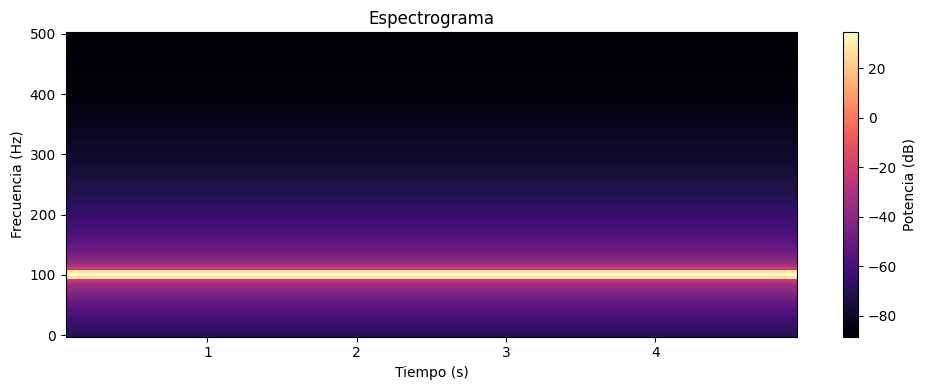

In [17]:
fm = 1000
fs = 100
t = np.arange(start=0,stop=5,step=1/fm)
x = np.sin(2*np.pi * fs * t)

times, freqs, S_db = generate_spectrogram(x,fm,window_size=200)
plot_spectogram(times,freqs,S_db)

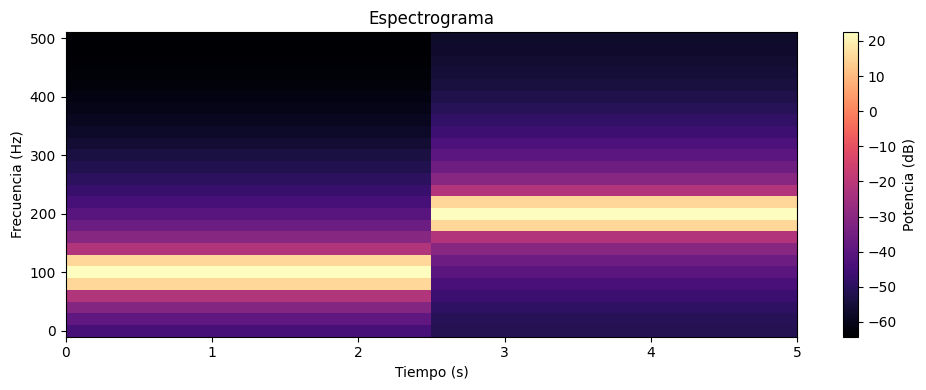

In [35]:
fm = 1000
t = np.arange(start=0,stop=5,step=1/fm)

x1 = np.sin(2*np.pi * 100 * t)
x2 = np.sin(2*np.pi * 200 * t)
x3 = np.concatenate((x1[:len(x1)//2],x2[len(x2)//2:]))

times, freqs, S_db = generate_spectrogram(x3,fm,window_size=50, n_overlap=0)
plot_spectogram(times,freqs,S_db)